<a href="https://colab.research.google.com/github/anuvishalp/Python_Projects/blob/main/Project-ETL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import pandas as pd
file_path='/content/drive/My Drive/Colab Notebooks/ecommerce_data_1000_rows.csv'
df=pd.read_csv(file_path)
df.head()

,OrderID,UserID,Category,Price,Quantity,OrderDate,PaymentMethod,Rating,TotalAmount
0,1001,2103,Beauty,8958.68,1,2023-01-01 00:00:00,Credit Card,3.0,8958.68
1,1002,2436,Beauty,5521.16,5,2023-01-01 01:00:00,Cash on Delivery,4.0,27605.80
2,1003,2861,Electronics,8191.25,3,2023-01-01 02:00:00,Net Banking,3.0,24573.75
3,1004,2271,Electronics,4577.95,3,2023-01-01 03:00:00,Credit Card,4.0,13733.85
4,1005,2107,Clothing,6471.42,3,2023-01-01 04:00:00,Credit Card,NaN,19414.26


In [4]:
import matplotlib.pyplot as plt

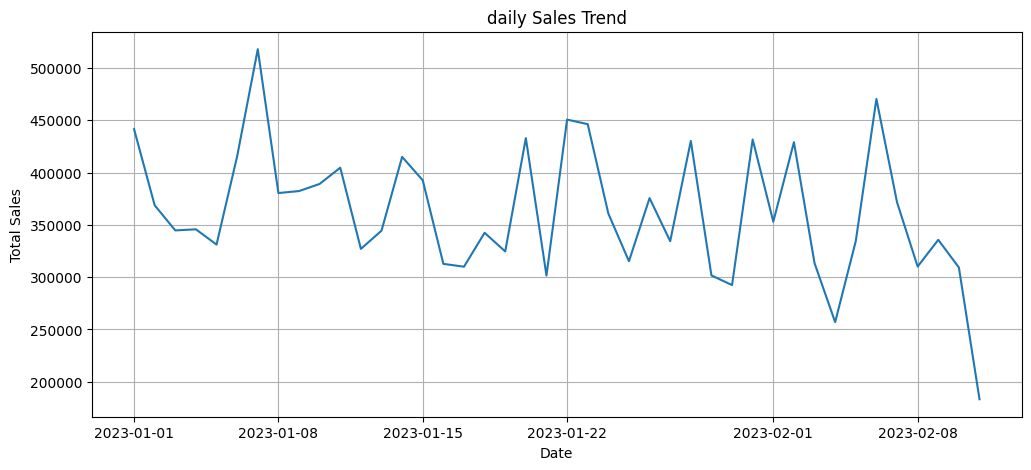

In [5]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
daily_sales=df.groupby(df['OrderDate'].dt.date)['TotalAmount'].sum()

daily_sales.plot(kind='line',figsize=(12,5))
plt.title("daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

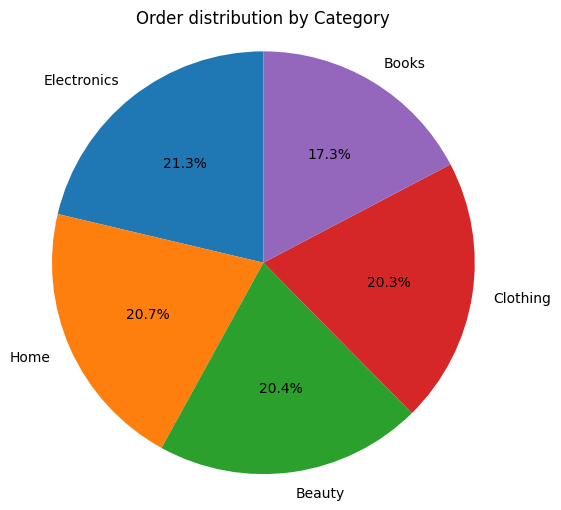

In [6]:
category_counts=df['Category'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(category_counts.values,
	labels=category_counts.index,
	autopct='%1.1f%%',
	startangle=90)

plt.title("Order distribution by Category")
plt.axis('equal')
plt.show()

In [7]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce')

In [8]:
df['OrderDateDate']=df['OrderDate'].dt.date

In [9]:
df['OrderHour']=df['OrderDate'].dt.hour

In [10]:
df['YearMonth']=df['OrderDate'].dt.to_period('M').astype(str)

In [11]:
if 'Rating' in df.columns:
	df['Rating'] = pd.to_numeric(df['Rating'],errors='coerce')

In [12]:
# recompute total to validate mismatches
df['TotalAmount_recalc']=df['Price'] * df['Quantity']
df.head()

,OrderID,UserID,Category,Price,Quantity,OrderDate,PaymentMethod,Rating,TotalAmount,OrderDateDate,OrderHour,YearMonth,TotalAmount_recalc
0,1001,2103,Beauty,8958.68,1,2023-01-01 00:00:00,Credit Card,3.0,8958.68,2023-01-01,0,2023-01,8958.68
1,1002,2436,Beauty,5521.16,5,2023-01-01 01:00:00,Cash on Delivery,4.0,27605.80,2023-01-01,1,2023-01,27605.80
2,1003,2861,Electronics,8191.25,3,2023-01-01 02:00:00,Net Banking,3.0,24573.75,2023-01-01,2,2023-01,24573.75
3,1004,2271,Electronics,4577.95,3,2023-01-01 03:00:00,Credit Card,4.0,13733.85,2023-01-01,3,2023-01,13733.85
4,1005,2107,Clothing,6471.42,3,2023-01-01 04:00:00,Credit Card,NaN,19414.26,2023-01-01,4,2023-01,19414.26


In [13]:
def h(n,title):
	print("\n" + "="*10 + f" o{n}: {title} " + "="*10)

In [14]:
#1 Total Revenue
h(1,"total revenue ( sum of Total(Amount)")
print(round(df['TotalAmount'].sum(),2))


========== o1: total revenue ( sum of Total(Amount) ==========
15232678.95


In [15]:
total_revenue = df['TotalAmount'].sum()
total_revenue

np.float64(15232678.95)

In [16]:
##2nd way of writing->rounding concept
total_revenue = round(df['TotalAmount'].sum(), 2)
total_revenue

np.float64(15232678.95)

In [17]:
##3. -> using aggregate function to calculate total_revenue
total_revenue = df['TotalAmount'].agg('sum')
total_revenue

np.float64(15232678.95)

In [18]:
#2 Unique orders and unique users
h(2,"unique orders and unique users")
print(f"Unique Orders: {df['OrderID'].nunique()}")
print(f"Unique Users: {df['UserID'].nunique()}")


========== o2: unique orders and unique users ==========
Unique Orders: 1000
Unique Users: 615


In [19]:
#3. Average Order value(AOV)
h(3,"Average order value (AOV)")
orders=df['OrderID'].nunique()
total_revenue=df['TotalAmount'].sum()
aov = total_revenue/orders if orders > 0 else 0
print(round(aov,2))


========== o3: Average order value (AOV) ==========
15232.68


In [20]:
#4 top-3 revenue generating categories

h(4,"top-3 revenue generating categories")

category_revenue = df.groupby('Category')['TotalAmount'].sum().sort_values(ascending=False)

top_categories = category_revenue.head(3)
print(top_categories)


========== o4: top-3 revenue generating categories ==========
Category
Clothing       3176933.44
Home           3129623.04
Electronics    3122119.43
Name: TotalAmount, dtype: float64


In [21]:
#5 Per category: orders, total_revenue, avg rating

h(5,"Per category: orders, total_revenue,avg rating")

category_stats=(
    df.groupby('Category')
      .agg(
          orders=('OrderID','nunique'),
          revenue=('TotalAmount','sum'),
          avg_rating=('Rating','mean')
      )
      .sort_values('revenue',ascending=False)
)

print(category_stats)



========== o5: Per category: orders, total_revenue,avg rating ==========
             orders     revenue  avg_rating
Category                                   
Clothing        203  3176933.44    3.149485
Home            207  3129623.04    3.010204
Electronics     213  3122119.43    3.160976
Beauty          204  3051628.53    3.132653
Books           173  2752374.51    3.175758


In [22]:
category_stats = (
    df.groupby('Category')
      .agg({
          'OrderID': 'nunique',
          'TotalAmount': 'sum',
          'Rating': 'mean'
      })
      .rename(columns={
          'OrderID': 'orders',
          'TotalAmount': 'revenue',
          'Rating': 'avg_rating'
      })
      .sort_values('revenue', ascending=False)
)


In [23]:
orders = df.groupby('Category')['OrderID'].nunique()
revenue = df.groupby('Category')['TotalAmount'].sum()
avg_rating = df.groupby('Category')['Rating'].mean()

category_stats = (
    pd.concat([orders, revenue, avg_rating], axis=1)
      .rename(columns={
          'OrderID': 'orders',
          'TotalAmount': 'revenue',
          'Rating': 'avg_rating'
      })
      .sort_values('revenue', ascending=False)
)


In [26]:
#6 Payment method with most revenue and its share

h(6,"Payment method with most revenue and its share")

pm=(df.groupby('PaymentMethod')
	  .agg(orders=('OrderID','nunique'), revenue=('TotalAmount','sum'),avg_rating=('Rating','mean'))
	  .sort_values('revenue',ascending=False))

pm['revenue_share_%'] = (pm['revenue']/pm['revenue'].sum() * 100).round(2)
print(pm)
print("top method by revenue:",pm.index[0],"| Share %:", pm.iloc[0]['revenue_share_%'])



========== o6: Payment method with most revenue and its share ==========
                  orders     revenue  avg_rating  revenue_share_%
PaymentMethod                                                    
Cash on Delivery     212  3408890.87    3.137931            22.38
Net Banking          189  3032806.32    3.129213            19.91
Credit Card          198  3026649.22    3.255208            19.87
UPI                  205  2887268.26    2.974619            18.95
Debit Card           196  2877064.28    3.129032            18.89
top method by revenue: Cash on Delivery | Share %: 22.38


In [27]:
#7 Orders per hour (peak hours)

h(7,"Orders per hour ( peak hours)")
orders_per_hour= df.groupby('OrderHour')['OrderID'].nunique().sort_index()
orders_per_hour


========== o7: Orders per hour ( peak hours) ==========


,OrderID
OrderHour,
0,42
1,42
2,42
3,42
4,42
5,42
6,42
7,42
8,42


In [28]:
#8 Revenue by month(YearMonth)
h(8,"Revenue by month(Year/Month)")
revenue_by_month=df.groupby('YearMonth')['TotalAmount'].sum().sort_index()
revenue_by_month


========== o8: Revenue by month(Year/Month) ==========


,TotalAmount
YearMonth,
2023-01,11565178.98
2023-02,3667499.97
